In [24]:

from simpeg.potential_fields import magnetics
from simpeg.utils import plot2Ddata, model_builder, download
from simpeg import (
    maps,
    data,
    data_misfit,
    inverse_problem,
    regularization,
    optimization,
    directives,
    inversion,
)

from discretize import TreeMesh
from discretize.utils import active_from_xyz
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import tarfile

mpl.rcParams.update({"font.size": 14})

In [25]:

data_source = "https://github.com/simpeg/user-tutorials/raw/main/assets/04-magnetics/inv_magnetics_induced_3d_files.tar.gz"
downloaded_data = download(data_source, overwrite=True)
tar = tarfile.open(downloaded_data, "r")
tar.extractall()
tar.close()
dir_path = downloaded_data.split(".")[0] + os.path.sep
topo_filename = dir_path + "magnetics_topo.txt"
data_filename = dir_path + "magnetics_data.obs"

overwriting C:\Users\Bardiya Sadraeifar\inv_magnetics_induced_3d_files.tar.gz
   saved to: C:\Users\Bardiya Sadraeifar\inv_magnetics_induced_3d_files.tar.gz
Download completed!


C:\Users\Bardiya Sadraeifar\AppData\Local\Temp\ipykernel_15928\3926027316.py:4: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


In [26]:

topo_xyz = np.loadtxt(str(topo_filename))
dobs = np.loadtxt(str(data_filename))

In [27]:

receiver_locations = dobs[:, 0:3]
dobs = dobs[:, -1]

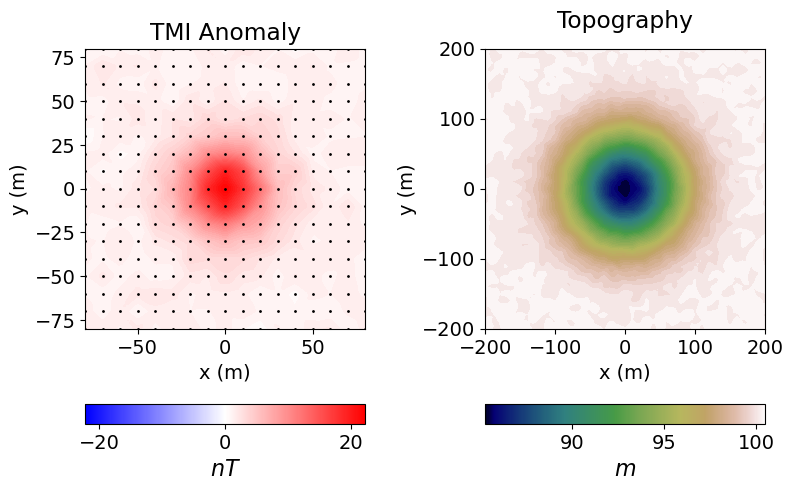

In [28]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_axes([0.05, 0.35, 0.35, 0.6])

v_max = np.max(np.abs(dobs))
norm1 = mpl.colors.Normalize(vmin=-v_max, vmax=v_max)

plot2Ddata(
    receiver_locations,
    dobs,
    ax=ax1,
    dataloc=True,
    ncontour=40,
    contourOpts={"cmap": mpl.cm.bwr, "norm": norm1},
)
ax1.set_title("TMI Anomaly")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("y (m)")

cx1 = fig.add_axes([0.05, 0.18, 0.35, 0.04])
cbar1 = mpl.colorbar.ColorbarBase(
    cx1, norm=norm1, orientation="horizontal", cmap=mpl.cm.bwr
)
cbar1.set_label("$nT$", size=16)

ax2 = fig.add_axes([0.55, 0.35, 0.35, 0.6])
plot2Ddata(
    topo_xyz[:, 0:2],
    topo_xyz[:, -1],
    ax=ax2,
    ncontour=50,
    contourOpts={"cmap": "gist_earth"},
)
ax2.set_title("Topography", pad=15)
ax2.set_xlabel("x (m)")
ax2.set_ylabel("y (m)")

cx2 = fig.add_axes([0.55, 0.18, 0.35, 0.04])
norm2 = mpl.colors.Normalize(vmin=np.min(topo_xyz[:, -1]), vmax=np.max(topo_xyz[:, -1]))
cbar2 = mpl.colorbar.ColorbarBase(
    cx2, norm=norm2, orientation="horizontal", cmap=mpl.cm.gist_earth
)
cbar2.set_label("$m$", size=16)

plt.show()

In [29]:
maximum_anomaly = np.max(np.abs(dobs))
floor_uncertainty = 0.02 * maximum_anomaly
uncertainties = floor_uncertainty * np.ones(np.shape(dobs))
print("Floor uncertainty: {}".format(floor_uncertainty))

Floor uncertainty: 0.44378


In [30]:

components = ["tmi"]
receiver_list = magnetics.receivers.Point(receiver_locations, components=components)
receiver_list = [receiver_list]
inclination = 90  # inclination [deg]
declination = 0  # declination [deg]
amplitude = 50000  # amplitude [nT]

source_field = magnetics.sources.UniformBackgroundField(
    receiver_list=receiver_list,
    amplitude=amplitude,
    inclination=inclination,
    declination=declination,
)

# Define the survey
survey = magnetics.survey.Survey(source_field)

In [31]:
data_object = data.Data(survey, dobs=dobs, standard_deviation=uncertainties)

In [32]:
dx = 5  # minimum cell width (base tree_mesh cell width) in x
dy = 5  # minimum cell width (base tree_mesh cell width) in y
dz = 5  # minimum cell width (base tree_mesh cell width) in z

x_length = 240.0  # domain width in x
y_length = 240.0  # domain width in y
z_length = 120.0  # domain width in z

# Compute number of base tree_mesh cells required in x and y
nbcx = 2 ** int(np.round(np.log(x_length / dx) / np.log(2.0)))
nbcy = 2 ** int(np.round(np.log(y_length / dy) / np.log(2.0)))
nbcz = 2 ** int(np.round(np.log(z_length / dz) / np.log(2.0)))

# Define the base tree_mesh
hx = [(dx, nbcx)]
hy = [(dy, nbcy)]
hz = [(dz, nbcz)]
tree_mesh = TreeMesh([hx, hy, hz], x0="CCN", diagonal_balance=True)

# Shift vertically to top same as maximum topography
tree_mesh.origin += np.r_[0.0, 0.0, topo_xyz[:, -1].max()]

# Refine based on surface topography
tree_mesh.refine_surface(topo_xyz, padding_cells_by_level=[2, 2], finalize=False)

# Refine box based on region of interest
wsb_corner = np.c_[-100, -100, 20]
ent_corner = np.c_[100, 100, 100]
# Note -1 is a flag for smallest cell size
tree_mesh.refine_box(wsb_corner, ent_corner, levels=[-1], finalize=False)

tree_mesh.finalize()

In [33]:
ind_tree_active = active_from_xyz(tree_mesh, topo_xyz)
n_tree_active = int(ind_tree_active.sum())

In [34]:
tree_model_map = maps.IdentityMap(nP=n_tree_active)

In [35]:
starting_tree_model = 1e-6 * np.ones(n_tree_active)
reference_tree_model = np.zeros_like(starting_tree_model)

In [36]:
# Mapping to ignore inactive cells when plotting
tree_plotting_map = maps.InjectActiveCells(tree_mesh, ind_tree_active, np.nan)


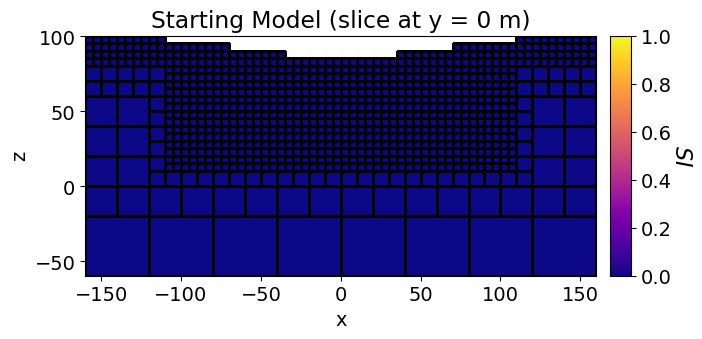

In [37]:
fig = plt.figure(figsize=(7, 3))
ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.8])

norm = mpl.colors.Normalize(vmin=0.0, vmax=1.0)
tree_mesh.plot_slice(
    tree_plotting_map * starting_tree_model,
    normal="Y",
    ax=ax1,
    ind=int(tree_mesh.shape_cells[1] / 2),
    grid=True,
    pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
)
ax1.set_title("Starting Model (slice at y = 0 m)")

ax2 = fig.add_axes([0.85, 0.1, 0.03, 0.8])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.plasma
)
cbar.set_label("$SI$", rotation=270, labelpad=15, size=16)

plt.show()


In [38]:
simulation_irls = magnetics.simulation.Simulation3DIntegral(
    survey=survey,
    mesh=tree_mesh,
    model_type="scalar",
    chiMap=tree_model_map,
    active_cells=ind_tree_active,
)

In [39]:
dmis_irls = data_misfit.L2DataMisfit(data=data_object, simulation=simulation_irls)

In [40]:
reg_irls = regularization.Sparse(
    tree_mesh,
    active_cells=ind_tree_active,
    alpha_s=0.05,
    alpha_x=1,
    alpha_y=1,
    alpha_z=1,
    reference_model=reference_tree_model,
    reference_model_in_smooth=False,
    norms=[0, 1, 1, 1],
)

In [41]:
opt_irls = optimization.ProjectedGNCG(
    maxIter=100, lower=0.0, maxIterLS=20, cg_maxiter=10, cg_rtol=1e-2
)

In [42]:
inv_prob_irls = inverse_problem.BaseInvProblem(dmis_irls, reg_irls, opt_irls)

In [43]:
sensitivity_weights_irls = directives.UpdateSensitivityWeights(every_iteration=False)
starting_beta_irls = directives.BetaEstimate_ByEig(beta0_ratio=10)
update_jacobi_irls = directives.UpdatePreconditioner(update_every_iteration=True)
update_irls = directives.UpdateIRLS(
    cooling_factor=2,
    f_min_change=1e-4,
    max_irls_iterations=25,
    chifact_start=1.0,
)

directives_list_irls = [
    update_irls,
    sensitivity_weights_irls,
    starting_beta_irls,
    update_jacobi_irls,
]

In [44]:
inv_irls = inversion.BaseInversion(inv_prob_irls, directives_list_irls)
recovered_tree_model = inv_irls.run(starting_tree_model)


Running inversion with SimPEG v0.25.2
================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  8.75e+07  2.68e+04  1.53e-08  2.68e+04                         0           inf          inf                
   1  8.75e+07  1.24e+04  5.55e-05  1.72e+04    4.03e+06      0      5        7.83e-03     3.19e+04              
   2  4.37e+07  7.43e+03  1.32e-04  1.32e+04    1.34e+06      0      5        6.74e-03     9.06e+03              
   3  2.19e+07  4.25e+03  2.34e-04  9.38e+03    7.53e+05      0      6        3.85e-03     2.90e+03              
   4  1.09e+07  2.22e+03  3.65e-04  6.21e+03    4.70e+05      0      6        5.63e-03     2.65e+03              
   5  5.47e+06  1.08e+03  5.09e-04  3.86e+03    

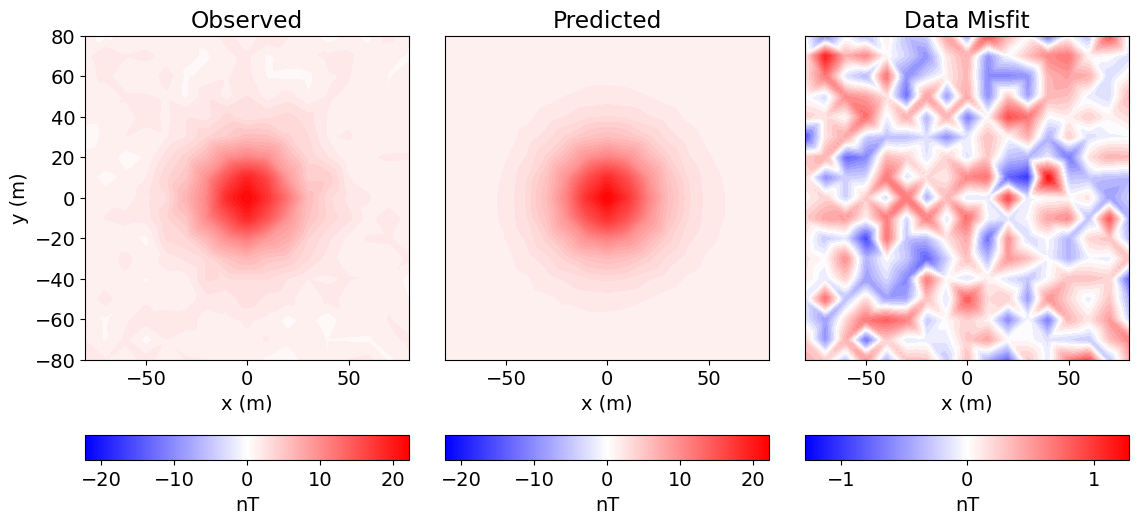

In [45]:
# Predicted data with final recovered model.
dpred_new = inv_prob_irls.dpred

# Observed data | Predicted data | Data misfit
data_array = np.c_[dobs, dpred_new, (dobs - dpred_new)]

fig = plt.figure(figsize=(12, 5))
plot_title = ["Observed", "Predicted", "Data Misfit"]
plot_units = ["nT", "nT", "nT"]

ax1 = 3 * [None]
ax2 = 3 * [None]
norm = 3 * [None]
cbar = 3 * [None]
cplot = 3 * [None]
v_lim = [np.max(np.abs(dobs)), np.max(np.abs(dobs)), np.max(np.abs(dobs - dpred_new))]

for ii in range(0, 3):
    ax1[ii] = fig.add_axes([0.3 * ii + 0.1, 0.2, 0.27, 0.75])
    norm[ii] = mpl.colors.Normalize(vmin=-v_lim[ii], vmax=v_lim[ii])
    cplot[ii] = plot2Ddata(
        receiver_list[0].locations,
        data_array[:, ii],
        ax=ax1[ii],
        ncontour=30,
        contourOpts={"cmap": "bwr", "norm": norm[ii]},
    )
    ax1[ii].set_title(plot_title[ii])
    ax1[ii].set_xlabel("x (m)")
    if ii == 0:
        ax1[ii].set_ylabel("y (m)")
    else:
        ax1[ii].set_yticks([])

    ax2[ii] = fig.add_axes([0.3 * ii + 0.1, 0.05, 0.27, 0.05])
    cbar[ii] = mpl.colorbar.ColorbarBase(
        ax2[ii], norm=norm[ii], orientation="horizontal", cmap=mpl.cm.bwr
    )
    cbar[ii].set_label(plot_units[ii], labelpad=5)

plt.show()

In [46]:
# Compute normalized data misfits
normalized_data_misfits = (dobs - dpred_new) / uncertainties


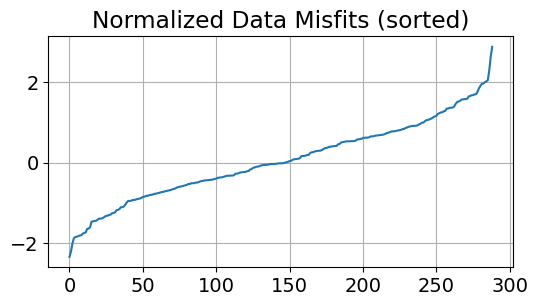

In [47]:
# Plot the normalized data misfits
fig = plt.figure(figsize=(6, 3))
ax = fig.add_subplot(111)
ax.plot(np.sort(normalized_data_misfits))
ax.set_title("Normalized Data Misfits (sorted)")
ax.grid()
plt.show(fig)


In [48]:
# Recreate True Model on the Tree Mesh
background_susceptibility = 0.0001
sphere_susceptibility = 0.01

true_model = background_susceptibility * np.ones(n_tree_active)
ind_sphere = model_builder.get_indices_sphere(
    np.r_[0.0, 0.0, 55.0], 16.0, tree_mesh.cell_centers[ind_tree_active]
)
true_model[ind_sphere] = sphere_susceptibility


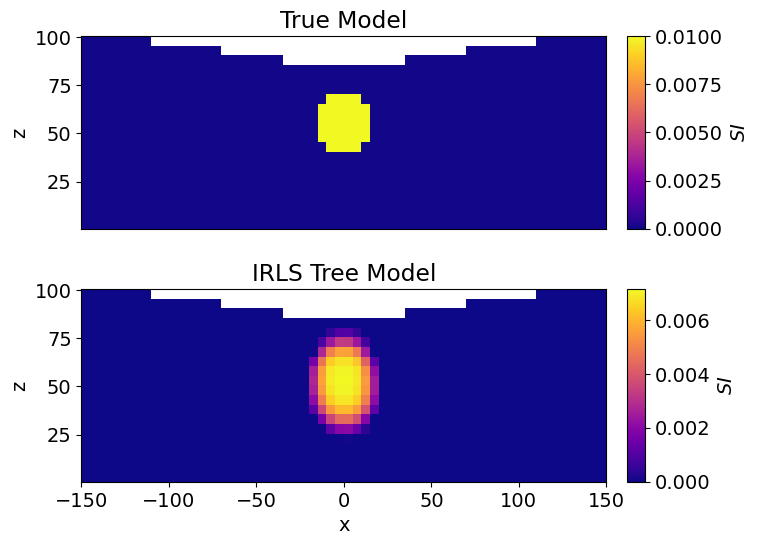

In [49]:
model_list = [true_model, recovered_tree_model]
title_list = ["True Model", "IRLS Tree Model"]
cplot = 2 * [None]
cbar = 2 * [None]
norm = 2 * [None]

fig = plt.figure(figsize=(7, 5.5))
ax1 = [fig.add_axes([0.1, 0.56 - 0.46 * ii, 0.75, 0.35]) for ii in range(0, 2)]
ax2 = [fig.add_axes([0.88, 0.56 - 0.46 * ii, 0.025, 0.35]) for ii in range(0, 2)]

for ii in range(0, 2):
    plotting_map = maps.InjectActiveCells(tree_mesh, ind_tree_active, np.nan)
    max_abs = np.max(np.abs(model_list[ii]))
    norm[ii] = mpl.colors.Normalize(vmin=0.0, vmax=max_abs)

    cplot[ii] = tree_mesh.plot_slice(
        plotting_map * model_list[ii],
        normal="Y",
        ax=ax1[ii],
        ind=int(tree_mesh.shape_cells[1] / 2),
        grid=False,
        pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm[ii]},
    )
    ax1[ii].set_xlim([-150, 150])
    ax1[ii].set_ylim([topo_xyz[:, -1].max() - 100, topo_xyz[:, -1].max()])
    if ii < 1:
        ax1[ii].set_xlabel("")
        ax1[ii].set_xticks([])
    ax1[ii].set_title(title_list[ii])

    cbar[ii] = mpl.colorbar.ColorbarBase(
        ax2[ii], norm=norm[ii], orientation="vertical", cmap=mpl.cm.plasma
    )
    cbar[ii].set_label("$SI$", labelpad=5)


# Uncertainty Assessment 1 — Exact Linearized Posterior Covariance (frozen-weight, data-space/Woodbury)

**Method (Family 1.1 of the review).** Around the converged mixed-norm model $m_{rec}$, freeze the IRLS and
sensitivity weights and adopt the linearized-Gaussian posterior

$$C_{post} = \Big( G_s^T G_s \;+\; \underbrace{\tfrac{\beta^*}{2}\,\nabla^2\phi_m(m_{rec})}_{A \,=\, C_0^{-1}} \Big)^{-1},
\qquad G_s = \mathrm{diag}(1/\sigma_d)\,G .$$

**Convention note (verified numerically in UQ-2).** SimPEG's $\phi_d = \|W r\|^2$ (no $\tfrac12$) and
`dmis.deriv2` $= 2G_s^TG_s$, while `reg.deriv2` is the true Hessian of $\phi_m$. Hence
$-\log p(m|d) = \tfrac12(\phi_d + \beta\phi_m)$ and the prior precision carries $\beta^*/2$ — equivalently
$C_{post} = 2\,H_{GN}^{-1}$. Using $\beta^*\,$`reg.deriv2` without the $\tfrac12$ overweights the prior and
shrinks every $\sigma$ by up to $\sqrt{2}$.

**Why this is exact here.** With $N = 289 \ll M$, the Woodbury identity
$C_{post} = A^{-1} - Y S^{-1} Y^T$, with $Y = A^{-1}G_s^T$ and $S = I_N + G_s Y$, needs only $N$ sparse solves.
The low-rank (data) correction and the resolution diagonal
$\mathrm{diag}(R)_i = [YS^{-1}]_i \cdot G_s[:,i]$ are then **exact**; the only estimated piece is
$\mathrm{diag}(A^{-1})$, computed exactly inside a region of interest and by Hutchinson probing (with
reported standard errors) elsewhere. Set `DIAG_MODE = "exact_full"` in UQ-4 for a fully exact map
(~30–40 min at this mesh size).

**Run after the inversion cells above.** Expected cost at ~44k active cells: ~20 s factorization,
~10 s for the 289 solves, seconds for Hutchinson, and a few minutes for the exact ROI (batch timing is printed).

**Interpretive caveats** (from the review): (i) everything is conditional on $\beta^*$ and the frozen
weights — this measures the *estimator's* stability, not distance to truth; (ii) with `norms=[0,1,1,1]`,
`mref=0` and `lower=0`, pinned cells have small $\sigma$ **by construction** (the frozen $L_0$ weights assert
zero); read those $\sigma$'s as "confident given the sparsity prior", and pair this map with the DOI mask
(Method 3 of our plan) before interpreting depth extent; (iii) the positivity bound truncates the Gaussian —
for probability statements near the bound prefer the RTO exceedance maps (Method 2).


In [50]:

import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import splu, cg, LinearOperator
import time

mrec = recovered_tree_model
beta_star = float(inv_prob_irls.beta)
n_active = int(ind_tree_active.sum())

G = simulation_irls.G                      
if not isinstance(G, np.ndarray):
    G = np.asarray(G)
N_data = G.shape[0]
Wd = 1.0 / uncertainties
Gs = Wd[:, None] * G                      

R2 = sp.csc_matrix(reg_irls.deriv2(mrec)) 
A = (0.5 * beta_star) * R2                 
A = A.tocsc()

diagA = A.diagonal()
assert np.all(np.isfinite(diagA)) and diagA.min() > 0, "reg Hessian diagonal not positive/finite"
print(f"N = {N_data} data | n_active = {n_active} cells | beta* = {beta_star:.4e}")
print(f"diag(A): min {diagA.min():.3e}, max {diagA.max():.3e}, dynamic range {diagA.max()/diagA.min():.2e}")
pinned_mask = mrec <= 1e-10
print(f"cells pinned at lower bound: {100*pinned_mask.mean():.1f}%")

N = 289 data | n_active = 43986 cells | beta* = 9.1327e+04
diag(A): min 8.370e+04, max 9.796e+08, dynamic range 1.17e+04
cells pinned at lower bound: 39.1%


In [51]:

rng_uq = np.random.default_rng(2026)
v_probe = rng_uq.standard_normal(n_active)

lhs = dmis_irls.deriv2(mrec, v_probe)
rhs = 2.0 * (Gs.T @ (Gs @ v_probe))
ratio_d = (v_probe @ lhs) / (v_probe @ rhs)
print(f"(a) v' dmis.deriv2 v / (2 v' Gs'Gs v) = {ratio_d:.6f}   (expect 1.0)")
assert abs(ratio_d - 1.0) < 1e-6, "dmis convention changed - revisit beta/2 factor"

w_probe = rng_uq.standard_normal(n_active)
sym_gap = abs(w_probe @ (R2 @ v_probe) - v_probe @ (R2 @ w_probe)) / abs(v_probe @ (R2 @ v_probe))
quad = v_probe @ (R2 @ v_probe)
print(f"(b) reg.deriv2 symmetry gap {sym_gap:.2e} (expect ~0), v'R2v = {quad:.3e} (expect > 0)")
assert sym_gap < 1e-8 and quad > 0
print("convention audit passed: C_post^{-1} = Gs'Gs + (beta*/2) reg.deriv2")

(a) v' dmis.deriv2 v / (2 v' Gs'Gs v) = 1.000000   (expect 1.0)
(b) reg.deriv2 symmetry gap 5.98e-18 (expect ~0), v'R2v = 5.840e+07 (expect > 0)
convention audit passed: C_post^{-1} = Gs'Gs + (beta*/2) reg.deriv2


In [52]:

t0 = time.time()
USE_SPLU = True
try:
    Alu = splu(A)
    A_solve = lambda B: Alu.solve(B)
    print(f"splu factorization: {time.time()-t0:.1f} s")
except MemoryError:
    USE_SPLU = False
    print("splu out of memory -> Jacobi-preconditioned CG fallback")
    Minv = sp.diags(1.0 / diagA)
    def _cg_solve_one(b):
        try:
            x, info = cg(A, b, M=Minv, rtol=1e-10, maxiter=2000)
        except TypeError:
            x, info = cg(A, b, M=Minv, tol=1e-10, maxiter=2000)
        assert info == 0, f"CG failed to converge (info={info})"
        return x
    def A_solve(B):
        if B.ndim == 1:
            return _cg_solve_one(B)
        return np.column_stack([_cg_solve_one(B[:, j]) for j in range(B.shape[1])])

# residual sanity on the factorization/solver
_x = rng_uq.standard_normal(n_active)
_res = np.linalg.norm(A @ A_solve(_x) - _x) / np.linalg.norm(_x)
print(f"A-solve relative residual: {_res:.2e}")
assert _res < 1e-8

t0 = time.time()
Y = A_solve(Gs.T)                          # n_active x N   -- the N exact solves
S = np.eye(N_data) + Gs @ Y                # innovation matrix, SPD
S = 0.5 * (S + S.T)
cS = np.linalg.cholesky(S)                 # also certifies SPD
YSinv = Y @ np.linalg.inv(S)
print(f"{N_data} exact solves + S factorization: {time.time()-t0:.1f} s")

corr_diag = np.einsum("ij,ij->i", YSinv, Y)          # exact low-rank variance correction
diagR = np.einsum("ij,ij->i", YSinv, Gs.T)           # exact resolution diagonal
eff_dof = diagR.sum()
print(f"diag(R): min {diagR.min():.2e}, max {diagR.max():.3f}; effective dof = {eff_dof:.1f} of N = {N_data}")

splu factorization: 42.0 s
A-solve relative residual: 1.01e-15
289 exact solves + S factorization: 9.9 s
diag(R): min 4.62e-07, max 0.259; effective dof = 20.0 of N = 289


In [53]:

DIAG_MODE  = "roi_exact"
ROI_RADIUS = 80.0          # m, horizontal
K_HUTCH    = 128           # Hutchinson probes
BATCH      = 512           # columns per exact batch

cc_active = tree_mesh.cell_centers[ind_tree_active]
w_cent = np.maximum(mrec, 0.0)
if w_cent.sum() > 0:
    centroid = (cc_active * w_cent[:, None]).sum(0) / w_cent.sum()
else:
    centroid = np.r_[0.0, 0.0, cc_active[:, 2].mean()]
roi_mask = np.linalg.norm(cc_active[:, :2] - centroid[:2], axis=1) <= ROI_RADIUS
print(f"anomaly centroid (weighted): {np.round(centroid, 1)} | ROI cells: {roi_mask.sum()} / {n_active}")

def diag_Ainv_hutch(K, seed=7):
    g = np.random.default_rng(seed)
    acc = np.zeros(n_active); acc2 = np.zeros(n_active)
    for _ in range(K):
        z = g.choice([-1.0, 1.0], size=n_active)
        t = z * A_solve(z)
        acc += t; acc2 += t * t
    est = acc / K
    se = np.sqrt(np.maximum(acc2 / K - est**2, 0.0) / K)
    return est, se

def diag_Ainv_exact(idx):
    idx = np.asarray(idx)
    out = np.empty(idx.size)
    for b0 in range(0, idx.size, BATCH):
        sel = idx[b0:b0 + BATCH]
        E = np.zeros((n_active, sel.size))
        E[sel, np.arange(sel.size)] = 1.0
        X = A_solve(E)
        out[b0:b0 + sel.size] = X[sel, np.arange(sel.size)]
    return out

t0 = time.time()
diagAinv_se = np.zeros(n_active)
exact_mask = np.zeros(n_active, dtype=bool)
if DIAG_MODE == "hutch":
    diagAinv, diagAinv_se = diag_Ainv_hutch(K_HUTCH)
elif DIAG_MODE == "exact_full":
    diagAinv = diag_Ainv_exact(np.arange(n_active))
    exact_mask[:] = True
else:  # roi_exact
    diagAinv, diagAinv_se = diag_Ainv_hutch(K_HUTCH)
    roi_idx = np.flatnonzero(roi_mask)
    diagAinv[roi_idx] = diag_Ainv_exact(roi_idx)
    diagAinv_se[roi_idx] = 0.0
    exact_mask[roi_idx] = True
print(f"diag(A^-1) [{DIAG_MODE}]: {time.time()-t0:.1f} s")

anomaly centroid (weighted): [-0.  -0.3 47. ] | ROI cells: 13297 / 43986
diag(A^-1) [roi_exact]: 463.7 s


In [54]:

diagC = diagAinv - corr_diag                       # diag(C_post)
neg_frac = np.mean(diagC < 0)
if neg_frac > 0:
    print(f"note: {100*neg_frac:.2f}% cells clipped at 0 (Hutchinson noise on prior term)")
sigma_post = np.sqrt(np.maximum(diagC, 0.0))
sigma_prior = np.sqrt(diagAinv)                    # prior (regularization-implied) std

# check 1: deflation -- posterior variance never exceeds prior variance (exact cells)
viol = np.sum(diagC[exact_mask] > diagAinv[exact_mask] * (1 + 1e-10)) if exact_mask.any() else 0
print(f"[check] posterior <= prior variance: {viol} violations in {exact_mask.sum()} exact cells")

# check 2: Woodbury vs direct solve of the full posterior precision
Hstat_mv = lambda v: Gs.T @ (Gs @ v) + A @ v
b_test = rng_uq.standard_normal(n_active)
x_wood = A_solve(b_test) - YSinv @ (Y.T @ b_test)
res_wood = np.linalg.norm(Hstat_mv(x_wood) - b_test) / np.linalg.norm(b_test)
print(f"[check] Woodbury inverse residual ||H x - b||/||b|| = {res_wood:.2e}")
assert res_wood < 1e-7

# check 3: C_post = 2 * H_GN^{-1} identity through SimPEG's own operators
hgn_v = dmis_irls.deriv2(mrec, x_wood) + beta_star * (R2 @ x_wood)
res_id = np.linalg.norm(0.5 * hgn_v - b_test) / np.linalg.norm(b_test)
print(f"[check] C_post = 2 H_GN^-1 identity residual = {res_id:.2e}")

print(f"sigma_post: min {sigma_post.min():.3e}, median {np.median(sigma_post):.3e}, "
      f"max {sigma_post.max():.3e} SI")
print(f"sigma_post at pinned cells (median): {np.median(sigma_post[pinned_mask]):.3e} SI "
      f"-- small by construction: the frozen L0 weights assert 'zero' strongly there")

[check] posterior <= prior variance: 0 violations in 13297 exact cells
[check] Woodbury inverse residual ||H x - b||/||b|| = 9.61e-15
[check] C_post = 2 H_GN^-1 identity residual = 3.87e-07
sigma_post: min 3.196e-05, median 2.351e-04, max 3.768e-03 SI
sigma_post at pinned cells (median): 2.531e-04 SI -- small by construction: the frozen L0 weights assert 'zero' strongly there


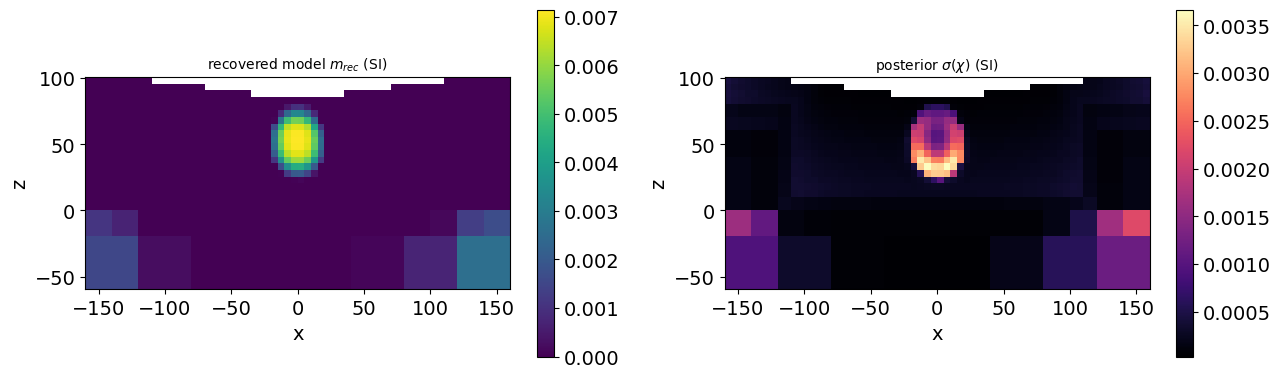

In [55]:

import matplotlib.pyplot as plt

plotting_map = maps.InjectActiveCells(tree_mesh, ind_tree_active, np.nan)

def _slice(ax, vec, title, cmap="viridis", norm_=None, clim=None):
    out = tree_mesh.plot_slice(plotting_map * vec, normal="Y", ax=ax, ind=int(tree_mesh.h[1].size / 2),
                               grid=False, pcolor_opts={"cmap": cmap, "norm": norm_,
                                                        **({"vmin": clim[0], "vmax": clim[1]} if clim else {})})
    ax.set_title(title, fontsize=10); ax.set_aspect(1)
    return out

fig, axs = plt.subplots(1, 2, figsize=(13, 4))
p0 = _slice(axs[0], mrec, "recovered model $m_{rec}$ (SI)")
plt.colorbar(p0[0], ax=axs[0])
p1 = _slice(axs[1], sigma_post, r"posterior $\sigma(\chi)$ (SI)", cmap="magma")
plt.colorbar(p1[0], ax=axs[1])
plt.tight_layout(); plt.show()

target cell 9381 at [-2.5 -2.5 53. ] | sigma = 9.589e-04 SI | strongest anticorrelation -0.04


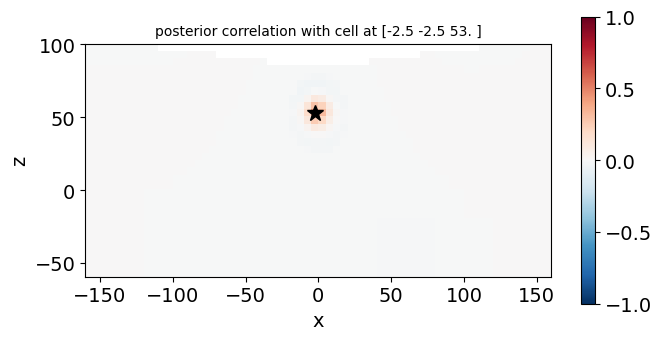

In [56]:

i_star = int(np.argmax(mrec))              # cell of max recovered susceptibility
e_i = np.zeros(n_active); e_i[i_star] = 1.0
cov_col = A_solve(e_i) - YSinv @ Y[i_star]           # C_post[:, i_star], exact
var_i = cov_col[i_star]
den = np.sqrt(np.maximum(diagC, 0.0) * var_i)
corr_col = np.divide(cov_col, den, out=np.zeros_like(cov_col), where=den > 0)
corr_col = np.clip(corr_col, -1, 1)

print(f"target cell {i_star} at {np.round(cc_active[i_star],1)} | "
      f"sigma = {np.sqrt(var_i):.3e} SI | strongest anticorrelation {corr_col.min():.2f}")

fig, ax = plt.subplots(1, 1, figsize=(7, 3.6))
pc = _slice(ax, corr_col, f"posterior correlation with cell at {np.round(cc_active[i_star],1)}",
            cmap="RdBu_r", clim=(-1, 1))
plt.colorbar(pc[0], ax=ax)
ax.plot(cc_active[i_star, 0], cc_active[i_star, 2], "k*", ms=12)
plt.tight_layout(); plt.show()

# Uncertainty Assessment 2 — Frozen-Weight Randomize-Then-Optimize (Family 4.1)

**Method.** Sample the same frozen-weight linearized posterior as Method 1, but as an *ensemble*: with
$H = C_{post}^{-1} = G_s^TG_s + A$ (conventions as in Method 1, $A = \tfrac{\beta^*}{2}\,$`reg.deriv2`),

$$m_k = m_{rec} + H^{-1}\big(G_s^T\varepsilon_k + w_k\big), \qquad \varepsilon_k \sim \mathcal{N}(0, I_N),\quad w_k \sim \mathcal{N}(0, A),$$

so that $\mathbb{E}[m_k] = m_{rec}$ and $\mathrm{Cov}[m_k] = C_{post}$ **exactly** (Bardsley et al., 2014: in the
linear-Gaussian case RTO is an exact posterior sampler). Each sample is one *direct* Woodbury solve — no CG,
no per-sample optimization — so the whole ensemble costs seconds once the Method-1 factorization exists
(RTO-1 rebuilds it automatically if you run this block standalone).

**The prior draw without a Cholesky.** RTO-2 verifies numerically that `reg.deriv2` $= c\sum_i\alpha_i B_i^TB_i$
with $B_i = W_i\,\partial f_i$ taken from SimPEG's own regularization objects (measured $c = 2$), then draws
$w = \sqrt{c\beta^*/2}\,\sum_i \sqrt{\alpha_i}\, B_i^T\delta_i$, which has covariance exactly $A$.

**Two ensembles, two uses.**
- **RAW** (unprojected): exactly $\mathcal{N}(m_{rec}, C_{post})$ — use it for CIs of linear functionals
  (moment, centroid numerator) where it is unbiased, and for the cross-check against Method 1.
- **PROJECTED** (clipped to $\chi \ge 0$): respects the bound — use it for exceedance maps
  $P(\chi > \chi_{cut})$ and percentile maps. **Warning validated in testing:** clipping only adds mass, so
  volume-integrated quantities (the moment) from the projected ensemble carry a positive truncation bias when
  a large fraction of values sits at the bound; RTO-6 therefore reports both tables side by side.

**Built-in cross-validation.** RTO-4 checks that the ensemble variance reproduces the Method-1
diag($C_{post}$) within the Monte-Carlo band $\pm 2\sqrt{2/K}$ — a joint correctness test of both notebooks.

**Caveats.** Same conditionality as Method 1: frozen IRLS weights, fixed $\beta^*$, and no sparsity-bias or
hyperparameter axis — the intervals describe reproducibility under data noise given this regularization.
Projection instead of Metropolization is the standard practical concession for bound constraints.


In [57]:
# ============================================================================
# RTO-1 | Setup: reuse the Method-1 factorization if present, else rebuild
# ----------------------------------------------------------------------------
# Sampler (linear-Gaussian, frozen weights):  with C_post^{-1} = H = Gs'Gs + A,
#   m_k = mrec + H^{-1} ( Gs' eps_k + w_k ),  eps_k ~ N(0, I_N),  w_k ~ N(0, A)
# => E[m_k] = mrec and Cov[m_k] = C_post exactly (before bound projection).
# Bardsley et al. (2014): for the linear-Gaussian case RTO samples the
# posterior exactly; the bound projection afterwards is the practical
# concession to chi >= 0 (samples are re-projected, not Metropolized).
# ============================================================================
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import splu, cg
import time

mrec = recovered_tree_model
beta_star = float(inv_prob_irls.beta)
n_active = int(ind_tree_active.sum())

if "A_solve" not in globals() or "YSinv" not in globals():
    print("Method-1 factorization not found in the namespace -> rebuilding (~3-4 min)")
    G = np.asarray(simulation_irls.G)
    Wd = 1.0 / uncertainties
    Gs = Wd[:, None] * G
    N_data = Gs.shape[0]
    R2 = sp.csc_matrix(reg_irls.deriv2(mrec))
    A = ((0.5 * beta_star) * R2).tocsc()
    assert np.all(np.isfinite(A.diagonal())) and A.diagonal().min() > 0
    Alu = splu(A)
    A_solve = lambda B: Alu.solve(B)
    Y = A_solve(Gs.T)
    S = np.eye(N_data) + Gs @ Y
    S = 0.5 * (S + S.T)
    np.linalg.cholesky(S)
    YSinv = Y @ np.linalg.inv(S)
else:
    print("reusing Gs, A, A_solve, Y, S, YSinv from the Method-1 cells")

if "rng_uq" not in globals():
    rng_uq = np.random.default_rng(2026)

def H_solve(B):
    """Exact C_post @ B via Woodbury (B: vector or (n_active x K) matrix)."""
    AB = A_solve(B)
    return AB - YSinv @ (Y.T @ B if B.ndim == 1 else Y.T @ B)

LOWER_BOUND = 0.0
UPPER_BOUND = None       # set if your ProjectedGNCG used an upper bound
print(f"N = {N_data}, n_active = {n_active}, beta* = {beta_star:.4e}")

reusing Gs, A, A_solve, Y, S, YSinv from the Method-1 cells
N = 289, n_active = 43986, beta* = 9.1327e+04


In [58]:
# ============================================================================
# RTO-2 | Prior-perturbation factorization audit (draws w ~ N(0, A) exactly)
# ----------------------------------------------------------------------------
# SimPEG's Sparse phi_m Hessian satisfies reg.deriv2 = c * sum_i alpha_i B_i'B_i
# with B_i = W_i @ f_m_deriv_i (c = 2 in v0.25.2; measured, not assumed).
# Then A = (beta*/2) reg.deriv2  =>  w = sqrt(c*beta*/2) * sum_i sqrt(alpha_i) B_i' d_i,
# d_i ~ N(0, I), has Cov(w) = A exactly. No Cholesky of A is needed.
# ============================================================================
prior_pieces = []
for alpha, obj in zip(reg_irls.multipliers, reg_irls.objfcts):
    B = (obj.W @ obj.f_m_deriv(mrec)).tocsr()
    prior_pieces.append((float(alpha), B))
    print(f"  {type(obj).__name__:18s} alpha = {alpha:g}  B: {B.shape}")

A_W = sum(alpha * (B.T @ B) for alpha, B in prior_pieces).tocsc()
ratios = []
for _ in range(5):
    v = rng_uq.standard_normal(n_active)
    ratios.append((v @ (R2 @ v)) / (v @ (A_W @ v)))
ratios = np.asarray(ratios)
c_fac = ratios.mean()
print(f"measured c = reg.deriv2 / sum(alpha B'B): {c_fac:.6f} (spread {np.ptp(ratios):.2e})")
assert np.ptp(ratios) < 1e-8, "factorization is not a constant multiple - do not sample from it"
prior_scale = np.sqrt(c_fac * beta_star / 2.0)

def draw_prior_perturbations(K, seed):
    g = np.random.default_rng(seed)
    Wp = np.zeros((n_active, K))
    for alpha, B in prior_pieces:
        D = g.standard_normal((B.shape[0], K))
        Wp += np.sqrt(alpha) * (B.T @ D)
    return prior_scale * Wp

  SparseSmallness    alpha = 0.05  B: (43986, 43986)
  SparseSmoothness   alpha = 1  B: (44076, 43986)
  SparseSmoothness   alpha = 1  B: (44077, 43986)
  SparseSmoothness   alpha = 1  B: (43922, 43986)
measured c = reg.deriv2 / sum(alpha B'B): 2.000000 (spread 4.44e-16)


In [59]:
# ============================================================================
# RTO-3 | Draw the ensemble (batched exact solves - no CG iterations)
# ============================================================================
K_RTO    = 256
RTO_SEED = 7

t0 = time.time()
Eps = np.random.default_rng(RTO_SEED).standard_normal((N_data, K_RTO))
Wp  = draw_prior_perturbations(K_RTO, seed=RTO_SEED + 1)
RHS = Gs.T @ Eps + Wp                          # (n_active x K)
U   = H_solve(RHS)                             # exact C_post * RHS, batched
samples_raw  = mrec[:, None] + U               # unprojected: exactly N(mrec, C_post)
samples_proj = np.clip(samples_raw, LOWER_BOUND, UPPER_BOUND)
print(f"{K_RTO} RTO samples in {time.time()-t0:.1f} s "
      f"({(time.time()-t0)/K_RTO*1e3:.0f} ms/sample)")

# how far is mrec from the frozen-quadratic MAP? (diagnostic for the centering)
d_s = (1.0 / uncertainties) * dobs
m_map = H_solve(Gs.T @ d_s + A @ np.zeros(n_active))   # mref = 0 in this notebook
gap = np.linalg.norm(m_map - mrec) / np.linalg.norm(mrec)
corr = np.corrcoef(m_map, mrec)[0, 1]
print(f"frozen-quadratic MAP vs mrec: rel diff {gap:.3f}, corr {corr:.3f} "
      f"(small gap justifies centering the sampler on mrec)")

clip_frac = np.mean(samples_raw < LOWER_BOUND)
print(f"fraction of sample values clipped at the lower bound: {100*clip_frac:.1f}%")

256 RTO samples in 10.7 s (42 ms/sample)
frozen-quadratic MAP vs mrec: rel diff 0.008, corr 1.000 (small gap justifies centering the sampler on mrec)
fraction of sample values clipped at the lower bound: 49.2%


In [60]:
# ============================================================================
# RTO-4 | Cross-validation against Method 1 (the two methods must agree)
# ----------------------------------------------------------------------------
# Unprojected sample variance must reproduce diag(C_post) within Monte Carlo
# error ~ sqrt(2/K).  This is a joint correctness test of BOTH notebooks.
# ============================================================================
svar = samples_raw.var(axis=1, ddof=1)
have_diagC = "diagC" in globals() and "exact_mask" in globals() and exact_mask.any()
if have_diagC:
    sel = exact_mask
    ratio = svar[sel] / diagC[sel]
    band = 2 * np.sqrt(2.0 / K_RTO)
    print(f"var(samples)/diag(C_post) over {sel.sum()} exact cells: "
          f"median {np.median(ratio):.3f}, IQR [{np.quantile(ratio,0.25):.3f}, {np.quantile(ratio,0.75):.3f}]")
    print(f"expected MC band around 1: +-{band:.3f}")
    ok = abs(np.median(ratio) - 1.0) < band
    print("[check] RTO ensemble reproduces the Method-1 posterior:", "PASS" if ok else "WARN")
else:
    print("Method-1 diagC not in namespace -> skipping the cross-check (run the Woodbury cells first)")

zmean = (samples_raw.mean(axis=1) - mrec) / (np.sqrt(svar / K_RTO) + 1e-300)
print(f"[check] sample-mean z-scores: median |z| = {np.median(np.abs(zmean)):.2f} (expect ~0.7)")

var(samples)/diag(C_post) over 13297 exact cells: median 0.997, IQR [0.938, 1.056]
expected MC band around 1: +-0.177
[check] RTO ensemble reproduces the Method-1 posterior: PASS
[check] sample-mean z-scores: median |z| = 0.68 (expect ~0.7)


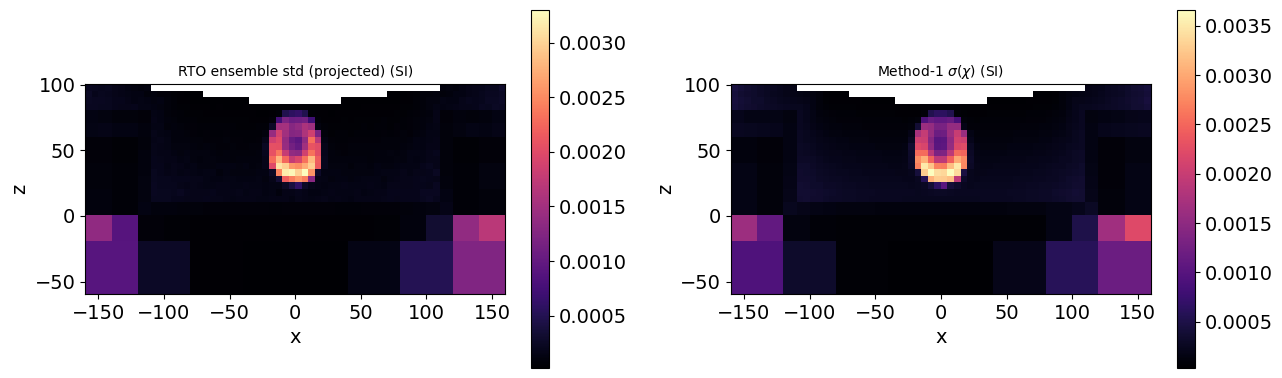

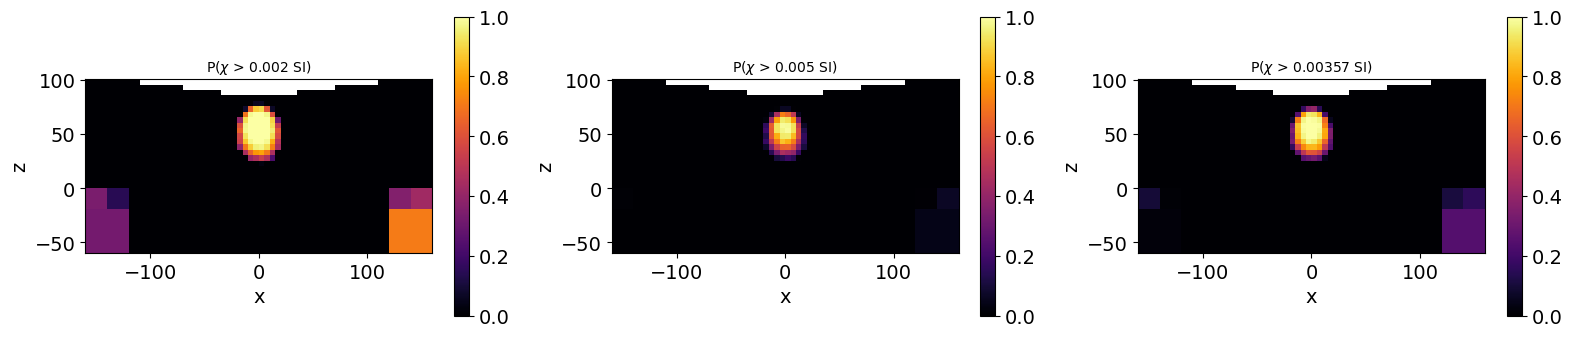

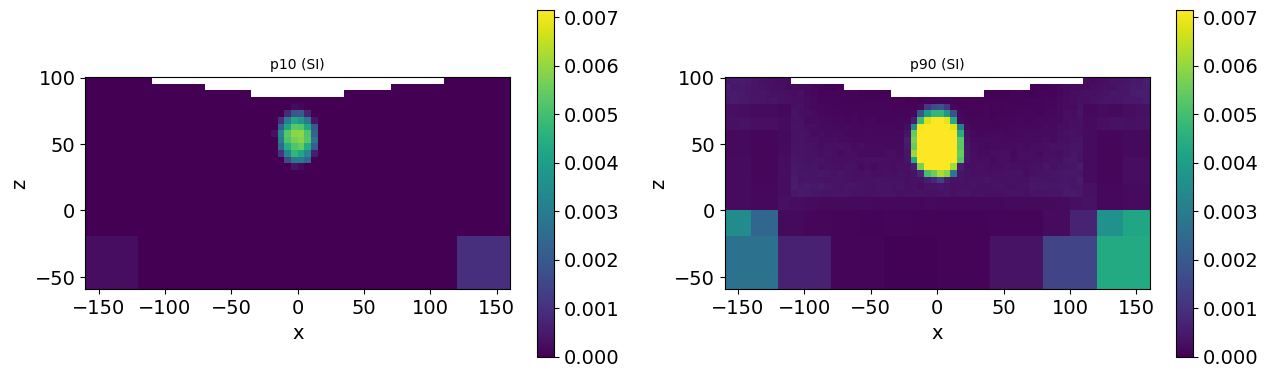

In [61]:
# ============================================================================
# RTO-5 | Maps: ensemble std, exceedance probabilities, percentiles
# ----------------------------------------------------------------------------
# All maps below use the PROJECTED ensemble (chi >= 0): near the bound the
# distribution is truncated and asymmetric, which is exactly what exceedance
# probabilities and percentiles are for (symmetric +-2 sigma would mislead).
# ============================================================================
import matplotlib.pyplot as plt

plotting_map = maps.InjectActiveCells(tree_mesh, ind_tree_active, np.nan)
def _slice(ax, vec, title, cmap="viridis", clim=None):
    out = tree_mesh.plot_slice(plotting_map * vec, normal="Y", ax=ax,
                               ind=int(tree_mesh.h[1].size / 2), grid=False,
                               pcolor_opts={"cmap": cmap,
                                            **({"vmin": clim[0], "vmax": clim[1]} if clim else {})})
    ax.set_title(title, fontsize=10); ax.set_aspect(1)
    return out

std_proj = samples_proj.std(axis=1, ddof=1)
cuts = [0.002, 0.005, 0.5 * mrec.max()]
exceed = {c: (samples_proj > c).mean(axis=1) for c in cuts}
p10, p90 = np.percentile(samples_proj, [10, 90], axis=1)

# std map: two panels only if the Method-1 sigma map exists in this session
have_m1 = "sigma_post" in globals()
fig, axs = plt.subplots(1, 2 if have_m1 else 1, figsize=(13 if have_m1 else 7, 4))
axs = np.atleast_1d(axs)
p0 = _slice(axs[0], std_proj, "RTO ensemble std (projected) (SI)", cmap="magma")
plt.colorbar(p0[0], ax=axs[0])
if have_m1:
    p1 = _slice(axs[1], sigma_post, r"Method-1 $\sigma(\chi)$ (SI)", cmap="magma")
    plt.colorbar(p1[0], ax=axs[1])
plt.tight_layout(); plt.show()

fig, axs = plt.subplots(1, 3, figsize=(16, 3.6))
for ax, c in zip(axs, cuts):
    pc = _slice(ax, exceed[c], f"P($\\chi$ > {c:.3g} SI)", cmap="inferno", clim=(0, 1))
    plt.colorbar(pc[0], ax=ax)
plt.tight_layout(); plt.show()

fig, axs = plt.subplots(1, 2, figsize=(13, 4))
pa = _slice(axs[0], p10, "p10 (SI)", clim=(0, mrec.max()))
plt.colorbar(pa[0], ax=axs[0])
pb = _slice(axs[1], p90, "p90 (SI)", clim=(0, mrec.max()))
plt.colorbar(pb[0], ax=axs[1])
plt.tight_layout(); plt.show()

# Uncertainty Assessment 3 — Depth of Investigation (Oldenburg & Li 1999, Family 2.2)

**Method.** Rerun the *identical* inversion with a shifted reference model and form
$$\mathrm{DOI}(r) = \frac{m_1(r) - m_2(r)}{m_{ref,1} - m_{ref,2}},$$
so DOI → 0 where the two runs agree (data-controlled) and DOI → 1 where each run echoes its own reference
(prior default — the axis that no $C_{post}$-based product from Methods 1–2 can see, because with `mref = 0`
and an $L_0$ smallness, "confidently zero" and "zero by default" produce the same $\sigma$).

**Two adaptations required for this problem, both discovered and validated in testing:**

1. **Each run must start at its own reference model.** Starting the companion at $10^{-6}$ leaves
   zero-sensitivity cells stuck near the start in *both* runs, falsely marking them data-controlled. Run 1
   started at $10^{-6} \approx$ its $m_{ref} = 0$, so the companion starts at `DOI_MREF`.
2. **The reference shift must be data-invisible (noise-calibrated).** TMI data over topography *see* a
   uniform susceptible background: with $m_{ref,2} = 0.005$ the data fight the reference everywhere, slam
   deep cells onto the $\chi \ge 0$ bound ($m \to 0$, not $m_{ref}$), and the companion overfits with wild
   amplitudes — the classic constant-shift recipe (built for DC resistivity, where a background shift is
   data-neutral) silently breaks. DOI-1 therefore sets
   $\Delta m_{ref} = \kappa\sqrt{N}\,/\,\lVert W_d\,G\,\mathbf{1}\rVert$ (default $\kappa = 0.5$): the whole-domain
   response of the shift sits at half the aggregate noise level, so unconstrained cells keep their reference
   and the DOI premise is restored.

**Consequence of the small shift.** Inside the anomaly the ratio divides solver-level differences by a tiny
denominator and is meaningless; the interpretability mask therefore has two clauses — amplitude agreement
($|\mathrm{DOI}| < 0.2$) **or** joint detection (both runs exceed a significance cut) — and the body is
certified by the second. Expect the interpretable fraction to be *small* (order 10%): with ~20 effective
degrees of freedom in 289 data, most of this 44k-cell volume genuinely is prior territory, and DOI is the
map that says so.

**Cost.** One extra full inversion (the simulation object is reused, so `G` is not recomputed).


In [62]:
# ============================================================================
# DOI-1 | Companion inversion: identical setup, shifted reference model
# ----------------------------------------------------------------------------
# Oldenburg & Li (1999): run the SAME inversion twice with different reference
# models; where the two results agree the data control the answer, where each
# result echoes its own mref the model is prior default. Everything below is a
# fresh copy of the original inversion objects (SimPEG directives are stateful
# and must not be reused) with ONE change: reference_model = DOI_MREF.
# The simulation is reused so the stored sensitivity G is not recomputed.
# ============================================================================
# --- noise-calibrated reference shift -------------------------------------
# TMI data SEE a uniform susceptible background (it produces a terrain-
# correlated anomaly), so a large constant mref shift is not data-neutral:
# the data fight the reference everywhere, push deep cells onto the chi>=0
# bound, and break the "unconstrained cells echo their mref" premise of DOI
# (validated: mref = 0.005 here drives deep cells to 0 and overfits).
# Fix: pick the shift so its whole-domain whitened response sits at
# BG_KAPPA * sqrt(N) -- i.e. at/below the noise floor, hence invisible to the
# data -- while still giving the ratio a well-defined denominator.
BG_KAPPA = 0.5
bg_resp = Gs @ np.ones(n_active) if "Gs" in globals() else           (1.0 / uncertainties) * (np.asarray(simulation_irls.G) @ np.ones(n_tree_active))
DOI_MREF = BG_KAPPA * np.sqrt(N_data) / np.linalg.norm(bg_resp)
print(f"noise-calibrated reference shift: DOI_MREF = {DOI_MREF:.3e} SI "
      f"(uniform-background response = {BG_KAPPA:.2f} sigma aggregate)")

reference_tree_model_2 = DOI_MREF * np.ones(n_tree_active)

dmis_doi = data_misfit.L2DataMisfit(data=data_object, simulation=simulation_irls)
reg_doi = regularization.Sparse(
    tree_mesh,
    active_cells=ind_tree_active,
    alpha_s=0.05, alpha_x=1, alpha_y=1, alpha_z=1,
    reference_model=reference_tree_model_2,
    reference_model_in_smooth=False,
    norms=[0, 1, 1, 1],
)
opt_doi = optimization.ProjectedGNCG(
    maxIter=100, lower=0.0, maxIterLS=20, cg_maxiter=10, cg_rtol=1e-2
)
inv_prob_doi = inverse_problem.BaseInvProblem(dmis_doi, reg_doi, opt_doi)
directives_doi = [
    directives.UpdateIRLS(cooling_factor=2, f_min_change=1e-4,
                          max_irls_iterations=25, chifact_start=1.0),
    directives.UpdateSensitivityWeights(every_iteration=False),
    directives.BetaEstimate_ByEig(beta0_ratio=10),
    directives.UpdatePreconditioner(update_every_iteration=True),
]
inv_doi = inversion.BaseInversion(inv_prob_doi, directives_doi)

# Oldenburg & Li convention: each run starts AT its own reference model, so
# cells the data cannot move stay at (and thus echo) their mref. Run 1 started
# at 1e-6 ~ its mref = 0; the companion must therefore start at DOI_MREF.
# (Validated: starting the companion at 1e-6 instead leaves zero-sensitivity
# cells stuck near the start in BOTH runs and falsely marks them data-controlled.)
t0 = time.time()
m_doi = inv_doi.run(reference_tree_model_2.copy())
phi_d_1 = float(dmis_irls(mrec))
phi_d_2 = float(dmis_doi(m_doi))
print(f"\ncompanion inversion done in {time.time()-t0:.0f} s")
print(f"phi_d: original {phi_d_1:.1f}, companion {phi_d_2:.1f}, N = {N_data} "
      f"(both should sit near the chi^2 target)")

noise-calibrated reference shift: DOI_MREF = 1.572e-05 SI (uniform-background response = 0.50 sigma aggregate)

Running inversion with SimPEG v0.25.2
================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  9.31e+07  2.55e+04  0.00e+00  2.55e+04                         0           inf          inf                
   1  9.31e+07  1.20e+04  4.97e-05  1.66e+04    3.82e+06      0      5        8.25e-03     3.18e+04              
   2  4.66e+07  7.46e+03  1.16e-04  1.29e+04    1.22e+06      0      6        4.06e-03     4.98e+03              
   3  2.33e+07  4.34e+03  2.11e-04  9.26e+03    7.30e+05      0      6        5.12e-03     3.74e+03              
   4  1.16e+07  2.28e+03  3.35e-04  6.19e+03    4.7

In [63]:
# ============================================================================
# DOI-2 | The DOI ratio and the interpretability mask
# ----------------------------------------------------------------------------
#   DOI(r) = ( m_1(r) - m_2(r) ) / ( mref_1 - mref_2 )
# mref_1 = 0 here, so DOI = (mrec - m_doi) / (0 - DOI_MREF).
#   DOI ~ 0 : both runs agree            -> data-controlled
#   DOI ~ 1 : each run returned its mref -> prior echo, do not interpret
# Values can leave [0,1] with IRLS (the two runs may re-shape compactness
# differently); we report the raw ratio but build the mask on |DOI|.
# ============================================================================
doi = (mrec - m_doi) / (0.0 - DOI_MREF)
# NB: with the noise-calibrated (small) shift, |DOI| inside the anomaly divides
# solver-level model differences by a small denominator and is NOT meaningful
# there; the joint-detection clause below is what certifies the body instead.

DOI_THRESH = 0.2                     # common choice 0.1 - 0.2
SIG_CUT    = 0.25 * mrec.max()       # joint-detection significance cut

# Interpretability = the two runs AGREE. Two ways to agree:
#  (a) amplitude agreement: |DOI| < DOI_THRESH (the classic L2 criterion);
#  (b) joint detection: BOTH runs demand a body there (m > SIG_CUT in each).
# Clause (b) is needed for sparse IRLS norms: the two runs can recover the
# same body with different compactness/amplitude, which inflates |DOI| inside
# the anomaly even though its presence is entirely data-driven.
amp_ok  = np.abs(doi) < DOI_THRESH
both_on = (mrec > SIG_CUT) & (m_doi > SIG_CUT)
interp_mask = amp_ok | both_on
print(f"mask components: amplitude-agreement {100*amp_ok.mean():.1f}%, "
      f"joint-detection adds {100*(both_on & ~amp_ok).mean():.1f}%")

frac_outside = np.mean((doi < -0.05) | (doi > 1.05))
print(f"DOI: median {np.median(doi):.3f}, p5 {np.percentile(doi,5):.3f}, "
      f"p95 {np.percentile(doi,95):.3f}, outside [0,1] (>5% margin): {100*frac_outside:.1f}% of cells")
for th in (0.1, 0.2, 0.4):
    print(f"  |DOI| < {th:>3}: {100*np.mean(np.abs(doi) < th):5.1f}% of active cells interpretable")

# consistency with Method 1's resolution diagonal, if available
if "diagR" in globals():
    hiR = diagR > 0.05
    loR = diagR < np.percentile(diagR, 25)
    print(f"[check] median |DOI| where diag(R) > 0.05: {np.median(np.abs(doi[hiR])):.3f} "
          f"(expect small)")
    print(f"[check] median |DOI| in lowest-resolution quartile: {np.median(np.abs(doi[loR])):.3f} "
          f"(expect near 1)")

mask components: amplitude-agreement 0.0%, joint-detection adds 0.7%
DOI: median 0.984, p5 0.672, p95 1.098, outside [0,1] (>5% margin): 12.2% of cells
  |DOI| < 0.1:   0.0% of active cells interpretable
  |DOI| < 0.2:   0.0% of active cells interpretable
  |DOI| < 0.4:   0.1% of active cells interpretable
[check] median |DOI| where diag(R) > 0.05: 18.004 (expect small)
[check] median |DOI| in lowest-resolution quartile: 0.823 (expect near 1)


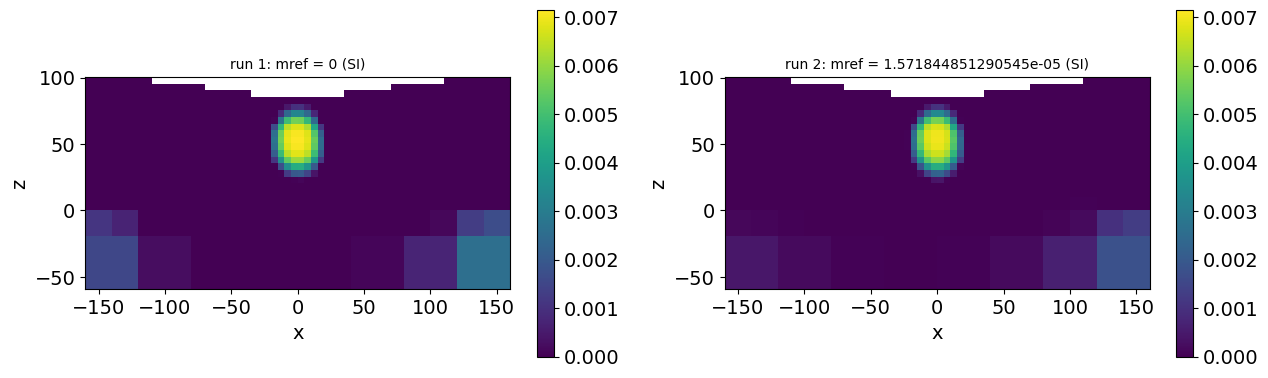

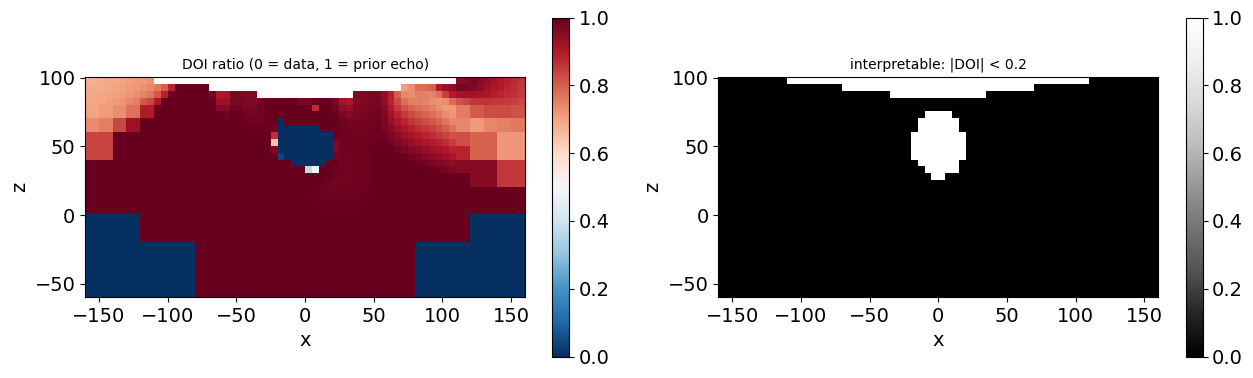

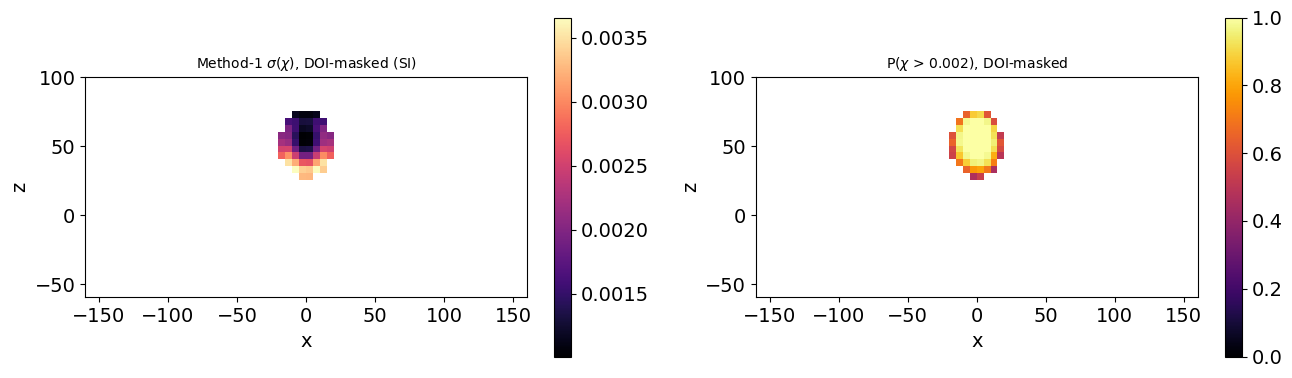

In [64]:
# ============================================================================
# DOI-3 | Figures: the two models, the DOI map, and DOI-masked UQ products
# ============================================================================
import matplotlib.pyplot as plt

if "plotting_map" not in globals():
    plotting_map = maps.InjectActiveCells(tree_mesh, ind_tree_active, np.nan)
if "_slice" not in globals():
    def _slice(ax, vec, title, cmap="viridis", clim=None):
        out = tree_mesh.plot_slice(plotting_map * vec, normal="Y", ax=ax,
                                   ind=int(tree_mesh.h[1].size / 2), grid=False,
                                   pcolor_opts={"cmap": cmap,
                                                **({"vmin": clim[0], "vmax": clim[1]} if clim else {})})
        ax.set_title(title, fontsize=10); ax.set_aspect(1)
        return out

# (a) the two inversions side by side -- inspect compactness differences (IRLS caveat)
vmax = max(mrec.max(), m_doi.max())
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
pa = _slice(axs[0], mrec, "run 1: mref = 0 (SI)", clim=(0, vmax))
plt.colorbar(pa[0], ax=axs[0])
pb = _slice(axs[1], m_doi, f"run 2: mref = {DOI_MREF} (SI)", clim=(0, vmax))
plt.colorbar(pb[0], ax=axs[1])
plt.tight_layout(); plt.show()

# (b) DOI map and the binary interpretability mask
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
pc = _slice(axs[0], doi, "DOI ratio (0 = data, 1 = prior echo)", cmap="RdBu_r", clim=(0, 1))
plt.colorbar(pc[0], ax=axs[0])
pd = _slice(axs[1], interp_mask.astype(float), f"interpretable: |DOI| < {DOI_THRESH}",
            cmap="Greys_r", clim=(0, 1))
plt.colorbar(pd[0], ax=axs[1])
plt.tight_layout(); plt.show()

# (c) DOI-masked uncertainty products (NaN outside the interpretable region)
masked = lambda v: np.where(interp_mask, v, np.nan)
panels = []
if "sigma_post" in globals():
    panels.append((masked(sigma_post), r"Method-1 $\sigma(\chi)$, DOI-masked (SI)", "magma", None))
if "exceed" in globals():
    c0 = sorted(exceed.keys())[0]
    panels.append((masked(exceed[c0]), f"P($\\chi$ > {c0:.3g}), DOI-masked", "inferno", (0, 1)))
if panels:
    fig, axs = plt.subplots(1, len(panels), figsize=(6.7 * len(panels), 4))
    axs = np.atleast_1d(axs)
    for ax, (v, t, cm, cl) in zip(axs, panels):
        pe = _slice(ax, v, t, cmap=cm, clim=cl)
        plt.colorbar(pe[0], ax=ax)
    plt.tight_layout(); plt.show()
else:
    print("sigma_post / exceed not in namespace -- run Methods 1-2 first for masked products")

# Uncertainty Assessment 4 — Point-Spread Functions and the Resolution Diagonal (Family 1.2)

**Method.** The resolution operator $R = C_{post}\,G_s^TG_s$ links the estimate to the truth,
$\hat m \approx R\,m_{true}$ (+ noise). Its diagonal — already computed exactly in UQ-3 as `diagR` — is the
per-cell *data-informed fraction* (note: with the audited conventions the identity is
$\mathrm{diag}(R) = 1 - \tfrac{\beta^*}{2}\mathrm{diag}(H^{-1}R'')$, the $\beta^*/2$ replacing the
$\beta^*$ of the naive formula). Its **columns** are point-spread functions: PSF$_i = H^{-1}G_s^TG_s\,e_i$
is the model the inversion would report for a unit delta at cell $i$ — one exact Woodbury solve each.

**Targets:** the anomaly center, a cell 30 m below it (the TMI depth-ambiguity probe), and a cell at the
edge of the resolved region. PSF-2 prints resolution metrics (peak displacement, vertical/horizontal FWHM);
vertical ≫ horizontal FWHM and upward peak shifts for deep targets are the quantitative face of the
depth-smearing that magnetics interpretation must respect.

**Cost:** seconds — requires the Method-1 factorization in the namespace (run UQ-1…UQ-5 first).
Validated against dense $R$ columns to ~10⁻¹⁴; PSF(target) ≡ diag(R)[target] by construction.

anomaly center         cell   9381 at [-2.5 -2.5 53. ]  diag(R) = 0.005
30 m below             cell   9090 at [-7.5 -7.5 23. ]  diag(R) = 0.000
resolved-region edge   cell  10899 at [-2.5 -2.5 73. ]  diag(R) = 0.039
target                   pk amp  @target   dz_pk   vFWHM   hFWHM     sum
anomaly center            0.006    0.005    -5.0    35.0    42.4    1.04
30 m below                0.003    0.000    15.0    20.0    39.1    0.41
resolved-region edge      0.040    0.039    -5.0    10.0    18.0    0.79

reading: 'amp at target' = diag(R) there; a perfect inversion gives a
delta (amp 1, FWHM one cell); TMI smearing shows as vertical FWHM >>
horizontal FWHM and upward/downward peak shifts for deep targets.


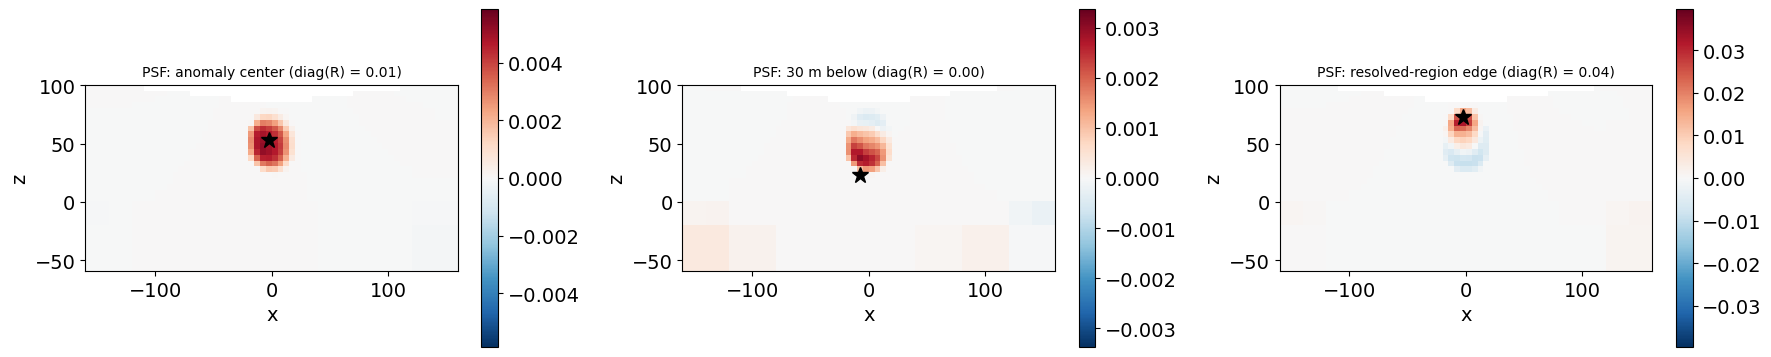

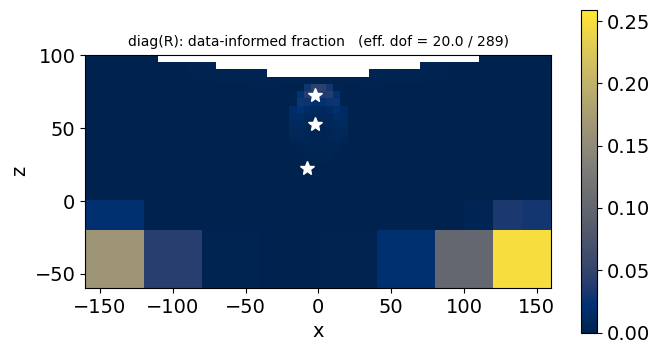

In [68]:
if "A_solve" not in globals() or "YSinv" not in globals():
    raise RuntimeError("Run the Method-1 (UQ) cells first - the factorization is required.")
if "H_solve" not in globals():
    def H_solve(B):
        AB = A_solve(B)
        return AB - YSinv @ (Y.T @ B if B.ndim == 1 else Y.T @ B)
if "cc_active" not in globals():
    cc_active = tree_mesh.cell_centers[ind_tree_active]

i_center = int(np.argmax(mrec))
xy0, z0 = cc_active[i_center, :2], cc_active[i_center, 2]

DEPTH_BELOW = 30.0                 # m below the anomaly-center cell
r_xy = np.linalg.norm(cc_active[:, :2] - xy0, axis=1)
cand = (r_xy < 10.0) & (cc_active[:, 2] < z0 - 0.5 * DEPTH_BELOW)
i_below = int(np.flatnonzero(cand)[np.argmin(np.abs(cc_active[cand, 2] - (z0 - DEPTH_BELOW)))]) \
          if cand.any() else i_center
r3d = np.linalg.norm(cc_active - cc_active[i_center], axis=1)
edge_band = (diagR > 0.03) & (diagR < 0.08) & (r3d > 15.0)   # distinct from the center
i_edge = int(np.flatnonzero(edge_band)[np.argmin(r_xy[edge_band])]) if edge_band.any() \
         else int(np.argmin(np.abs(diagR - 0.05) + 1e9 * (r3d < 15.0)))

targets = {"anomaly center": i_center, f"{DEPTH_BELOW:.0f} m below": i_below,
           "resolved-region edge": i_edge}
for name, i in targets.items():
    print(f"{name:22s} cell {i:6d} at {np.round(cc_active[i], 1)}  diag(R) = {diagR[i]:.3f}")


def psf_of(i):
    e = np.zeros(n_active); e[i] = 1.0
    return H_solve(Gs.T @ (Gs @ e))          # column i of R, exact

psfs = {name: psf_of(i) for name, i in targets.items()}

def psf_metrics(p, i):
    j_pk = int(np.argmax(p))
    shift = cc_active[j_pk] - cc_active[i]
    half = p > 0.5 * p[j_pk]
    dz = cc_active[half, 2]; dxy = cc_active[half, :2]
    return {"peak amp": p[j_pk], "amp at target": p[i],
            "peak shift dz [m]": shift[2],
            "vertical FWHM [m]": dz.max() - dz.min() if half.sum() > 1 else 0.0,
            "horiz FWHM [m]": np.linalg.norm(dxy.max(0) - dxy.min(0)) if half.sum() > 1 else 0.0,
            "sum(PSF)": p.sum()}

print(f"{'target':22s}{'pk amp':>9s}{'@target':>9s}{'dz_pk':>8s}{'vFWHM':>8s}{'hFWHM':>8s}{'sum':>8s}")
for name, i in targets.items():
    m_ = psf_metrics(psfs[name], i)
    print(f"{name:22s}{m_['peak amp']:9.3f}{m_['amp at target']:9.3f}"
          f"{m_['peak shift dz [m]']:8.1f}{m_['vertical FWHM [m]']:8.1f}"
          f"{m_['horiz FWHM [m]']:8.1f}{m_['sum(PSF)']:8.2f}")
print("\nreading: 'amp at target' = diag(R) there; a perfect inversion gives a")
print("delta (amp 1, FWHM one cell); TMI smearing shows as vertical FWHM >>")
print("horizontal FWHM and upward/downward peak shifts for deep targets.")
import matplotlib.pyplot as plt

if "plotting_map" not in globals():
    plotting_map = maps.InjectActiveCells(tree_mesh, ind_tree_active, np.nan)
if "_slice" not in globals():
    def _slice(ax, vec, title, cmap="viridis", clim=None):
        out = tree_mesh.plot_slice(plotting_map * vec, normal="Y", ax=ax,
                                   ind=int(tree_mesh.h[1].size / 2), grid=False,
                                   pcolor_opts={"cmap": cmap,
                                                **({"vmin": clim[0], "vmax": clim[1]} if clim else {})})
        ax.set_title(title, fontsize=10); ax.set_aspect(1)
        return out

fig, axs = plt.subplots(1, len(targets), figsize=(6.0 * len(targets), 3.8))
axs = np.atleast_1d(axs)
for ax, (name, i) in zip(axs, targets.items()):
    p = psfs[name]
    vmax = np.abs(p).max()
    pc = _slice(ax, p, f"PSF: {name} (diag(R) = {diagR[i]:.2f})",
                cmap="RdBu_r", clim=(-vmax, vmax))
    plt.colorbar(pc[0], ax=ax)
    ax.plot(cc_active[i, 0], cc_active[i, 2], "k*", ms=12)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 1, figsize=(7, 3.8))
pr = _slice(ax, diagR, f"diag(R): data-informed fraction   (eff. dof = {diagR.sum():.1f} / {N_data})",
            cmap="cividis", clim=(0, diagR.max()))
plt.colorbar(pr[0], ax=ax)
for name, i in targets.items():
    ax.plot(cc_active[i, 0], cc_active[i, 2], "w*", ms=10)
plt.tight_layout(); plt.show()